In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Tải dữ liệu Fashion-MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Chuẩn hóa
X_train = X_train / 255.0
X_test = X_test / 255.0

# Mô phỏng thêm 5 lớp dữ liệu tự thu thập
# 5 lớp mới được tạo bằng noise để minh hoạ
num_new_classes = 5
samples_per_new_class = 1000

X_new = np.random.rand(num_new_classes * samples_per_new_class, 28, 28)
y_new = np.repeat(np.arange(10, 15), samples_per_new_class)

# Gộp dữ liệu lại
X_train_all = np.concatenate([X_train, X_new], axis=0)
y_train_all = np.concatenate([y_train, y_new], axis=0)

# Shuffle
idx = np.random.permutation(len(X_train_all))
X_train_all, y_train_all = X_train_all[idx], y_train_all[idx]

# One-hot encoding
y_train_all_oh = to_categorical(y_train_all, 15)
y_test_oh = to_categorical(y_test, 15)

print("Kích thước train:", X_train_all.shape)
print("Kích thước test:", X_test.shape)
print("Số lớp:", y_train_all_oh.shape[1])


Kích thước train: (65000, 28, 28)
Kích thước test: (10000, 28, 28)
Số lớp: 15


Train samples: 60000
Test samples : 10000
Input shape (per sample): (28, 28)
X_train dtype: float64
y_train dtype: uint8
Number of classes: 10
   class_id  count  percentage
0         0   6000        10.0
1         1   6000        10.0
2         2   6000        10.0
3         3   6000        10.0
4         4   6000        10.0
5         5   6000        10.0
6         6   6000        10.0
7         7   6000        10.0
8         8   6000        10.0
9         9   6000        10.0


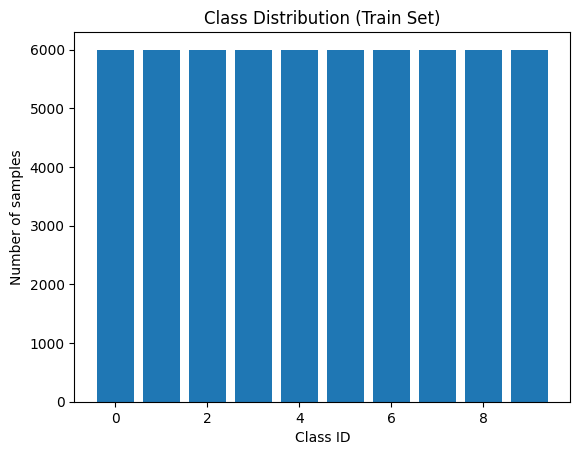

Pixel min: 0.0
Pixel max: 1.0
Pixel mean: 0.2860405969887955
Pixel std : 0.35302424451492237


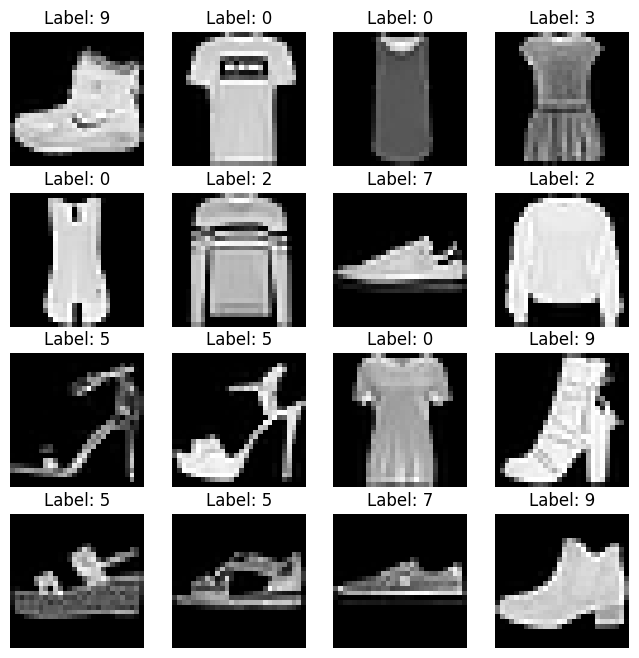

{'train_samples': 60000,
 'test_samples': 10000,
 'image_height': 28,
 'image_width': 28,
 'channels': 1,
 'num_classes': 10}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# BASIC SIZE & SHAPE
print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

print("Input shape (per sample):", X_train.shape[1:])

print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

# CLASS DISTRIBUTION
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

class_counts = np.bincount(y_train, minlength=num_classes)
class_dist = pd.DataFrame({
    "class_id": np.arange(num_classes),
    "count": class_counts,
    "percentage": class_counts / class_counts.sum() * 100
})

print(class_dist)

# VISUALIZE CLASS DISTRIBUTION
plt.figure()
plt.bar(class_dist["class_id"], class_dist["count"])
plt.xlabel("Class ID")
plt.ylabel("Number of samples")
plt.title("Class Distribution (Train Set)")
plt.show()

# PIXEL VALUE STATISTICS
print("Pixel min:", X_train.min())
print("Pixel max:", X_train.max())
print("Pixel mean:", X_train.mean())
print("Pixel std :", X_train.std())

# SAMPLE IMAGE GRID (SANITY CHECK)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# SUMMARY (PROGRAMMATIC)
summary = {
    "train_samples": X_train.shape[0],
    "test_samples": X_test.shape[0],
    "image_height": X_train.shape[1],
    "image_width": X_train.shape[2],
    "channels": 1 if X_train.ndim == 3 else X_train.shape[-1],
    "num_classes": num_classes,
}

summary


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(15, activation='softmax')  # Softmax output
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 263,759 (1.01 MB)

 Trainable params: 263,759 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train_all, y_train_all_oh,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7291 - loss: 0.7123 - val_accuracy: 0.7415 - val_loss: 0.6793
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8002 - loss: 0.5036 - val_accuracy: 0.7769 - val_loss: 0.5534
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8138 - loss: 0.4660 - val_accuracy: 0.7471 - val_loss: 0.7194
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8239 - loss: 0.4418 - val_accuracy: 0.8295 - val_loss: 0.4267
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8313 - loss: 0.4184 - val_accuracy: 0.8322 - val_loss: 0.4210
Epoch 6/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8376 - loss: 0.4004 - val_accuracy: 0.8300 - val_loss: 0.4393
Epoch 7/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8426 - loss: 0.3852 - val_accuracy: 0.8186 - val_loss: 0.4469
Epoch 8/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8443 - loss: 0.3804 - val_accuracy: 0

In [5]:
loss, acc = model.evaluate(X_test, y_test_oh)
print("Test accuracy:", acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8765 - loss: 0.3466
Test accuracy: 0.8765000104904175


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


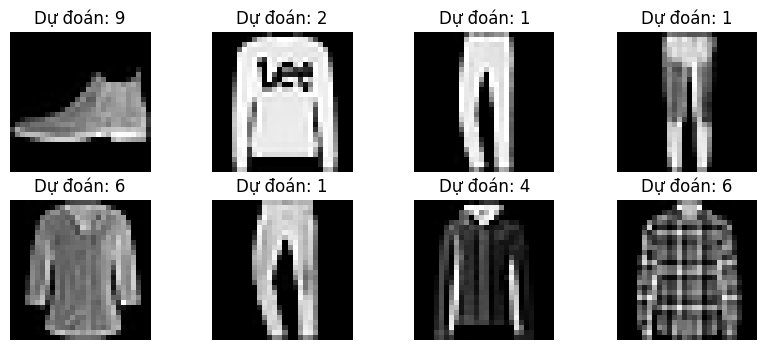

In [6]:
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[i], cmap="gray")
    pred = np.argmax(model.predict(X_test[i].reshape(1,28,28)))
    plt.title(f"Dự đoán: {pred}")
    plt.axis("off")
plt.show()
